# Test the four RUGD-trained checkpoints on RELLIS-3D

This notebook evaluates four RUGD-trained binary ground/non-ground segmentation models on the RELLIS-3D test set:

- U-Net: `segmentation_models_pytorch.Unet`, ResNet-34 encoder
- DeepLabV3+: `segmentation_models_pytorch.DeepLabV3Plus`, ResNet-34 encoder, output stride 16
- SegFormer-B0: `segmentation_models_pytorch.Segformer`, MiT-B0 encoder
- ROD: EfficientSAM-S encoder + ROD segmentation decoder

This is a zero-shot cross-dataset experiment:

**RUGD training → RELLIS-3D testing**

For the first three models, the preprocessing exactly follows their training notebooks:
- direct resize to `512 × 512`;
- ImageNet normalization.

For ROD, the preprocessing follows the original ROD training/cross-dataset implementation:
- preserve aspect ratio;
- resize and pad to `512 × 512`;
- ImageNet-equivalent normalization in the original 0–255 scale;
- EfficientSAM internally receives `1024 × 1024`;
- the padded prediction is restored to the original image resolution before metric calculation.

All models use:
- two classes: `0 = non-ground`, `1 = ground`;
- ignore index: `255`;
- the same RELLIS-3D binary test split;
- the same global confusion-matrix metric definitions.

In [1]:
# Install the libraries used by the baseline notebooks.
!pip -q install segmentation-models-pytorch timm

# Clone the original ROD repository.
import os
import sys

ROD_REPO = "/content/offroad_roadseg"

if not os.path.exists(ROD_REPO):
    !git clone --depth 1 https://github.com/ict-ans-617/offroad_roadseg.git {ROD_REPO}

if ROD_REPO not in sys.path:
    sys.path.insert(0, ROD_REPO)

print("ROD repository:", ROD_REPO)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 3.3 MB/s eta 0:00:00
Cloning into '/content/offroad_roadseg'...
remote: Enumerating objects: 80, done.
remote: Counting objects: 100% (80/80), done.
remote: Compressing objects: 100% (62/62), done.
remote: Total 80 (delta 17), reused 78 (delta 17), pack-reused 0 (from 0)
Receiving objects: 100% (80/80), 4.32 MiB | 21.48 MiB/s, done.
Resolving deltas: 100% (17/17), done.
ROD repository: /content/offroad_roadseg


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


## 1. Configuration

Modify the paths and model settings below.

The default dataset ZIP is expected to contain:

```text
RELLIS_3D_binary_processed/
├── images/
│   └── test/
└── masks/
    └── test/
```


In [3]:
from pathlib import Path

DATASET_ZIP = Path(
    "/content/drive/MyDrive/IRP/01_data/processed/RELLIS_3D_binary_processed.zip"
)

CHECKPOINTS = {
    "U-Net": Path(
        "/content/drive/MyDrive/IRP/02_in_domain_rugd/checkpoints/"
        "unet_resnet34_rugd_binary_ground_best_20epochs.pth"
    ),
    "DeepLabV3+": Path(
        "/content/drive/MyDrive/IRP/02_in_domain_rugd/checkpoints/"
        "deeplabv3plus_resnet34_rugd_binary_ground_best_20epochs.pth"
    ),
    "SegFormer-B0": Path(
        "/content/drive/MyDrive/IRP/02_in_domain_rugd/checkpoints/"
        "segformer_b0_rugd_binary_ground_best_20epochs.pth"
    ),
    "ROD": Path(
        "/content/drive/MyDrive/IRP/02_in_domain_rugd/checkpoints/"
        "rod_rugd_binary_ground_best_20epochs.pth"
    ),
}

LOCAL_DATA_ROOT = Path("/content/rellis_test_data")
RESULTS_ROOT = Path(
    "/content/drive/MyDrive/IRP/03_cross_dataset/rugd_to_rellis3d"
)

NON_GROUND_CLASS = 0
GROUND_CLASS = 1
IGNORE_INDEX = 255
NUM_CLASSES = 2

BATCH_SIZE = 8
ROD_BATCH_SIZE = 1
NUM_WORKERS = 2
PIN_MEMORY = True

MODEL_CONFIGS = {
    "U-Net": {
        "input_size": (512, 512),
        "normalization": "imagenet",
        "encoder_name": "resnet34",
        "preprocess_mode": "direct_resize",
    },
    "DeepLabV3+": {
        "input_size": (512, 512),
        "normalization": "imagenet",
        "encoder_name": "resnet34",
        "encoder_output_stride": 16,
        "preprocess_mode": "direct_resize",
    },
    "SegFormer-B0": {
        "input_size": (512, 512),
        "normalization": "imagenet",
        "encoder_name": "mit_b0",
        "preprocess_mode": "direct_resize",
    },
    "ROD": {
        "input_size": (512, 512),
        "normalization": "rod_imagenet_255",
        "encoder_name": "EfficientSAM-S",
        "preprocess_mode": "aspect_ratio_pad",
        "encoder_input_size": (1024, 1024),
    },
}

print("Dataset ZIP:", DATASET_ZIP)
for model_name, checkpoint_path in CHECKPOINTS.items():
    print(f"{model_name}: {checkpoint_path}")

Dataset ZIP: /content/drive/MyDrive/IRP/01_data/processed/RELLIS_3D_binary_processed.zip
U-Net: /content/drive/MyDrive/IRP/02_in_domain_rugd/checkpoints/unet_resnet34_rugd_binary_ground_best_20epochs.pth
DeepLabV3+: /content/drive/MyDrive/IRP/02_in_domain_rugd/checkpoints/deeplabv3plus_resnet34_rugd_binary_ground_best_20epochs.pth
SegFormer-B0: /content/drive/MyDrive/IRP/02_in_domain_rugd/checkpoints/segformer_b0_rugd_binary_ground_best_20epochs.pth
ROD: /content/drive/MyDrive/IRP/02_in_domain_rugd/checkpoints/rod_rugd_binary_ground_best_20epochs.pth


## 2. Validate paths and extract the dataset

The dataset is extracted to Colab local storage for faster reading.


In [4]:
import shutil
import zipfile

if not DATASET_ZIP.exists():
    raise FileNotFoundError(
        f"Dataset ZIP not found: {DATASET_ZIP}\n"
        "Update DATASET_ZIP to the correct Google Drive path."
    )

missing_checkpoints = [
    (name, path)
    for name, path in CHECKPOINTS.items()
    if not path.exists()
]

if missing_checkpoints:
    print("Missing checkpoints:")
    for name, path in missing_checkpoints:
        print(f"  {name}: {path}")
    raise FileNotFoundError(
        "One or more checkpoint paths are incorrect."
    )

extract_marker = LOCAL_DATA_ROOT / ".extract_complete"

if not extract_marker.exists():
    if LOCAL_DATA_ROOT.exists():
        shutil.rmtree(LOCAL_DATA_ROOT)

    LOCAL_DATA_ROOT.mkdir(parents=True, exist_ok=True)

    print(f"Extracting {DATASET_ZIP.name}...")
    with zipfile.ZipFile(DATASET_ZIP, "r") as zf:
        zf.extractall(LOCAL_DATA_ROOT)

    extract_marker.touch()
    print("Extraction completed.")
else:
    print("Dataset already extracted in this Colab session.")


Extracting RELLIS_3D_binary_processed.zip...
Extraction completed.


In [5]:
def find_processed_root(search_root: Path) -> Path:
    candidates = [search_root] + [
        p for p in search_root.rglob("*") if p.is_dir()
    ]

    for candidate in candidates:
        image_test = candidate / "images" / "test"
        mask_test = candidate / "masks" / "test"

        if image_test.is_dir() and mask_test.is_dir():
            return candidate

    raise FileNotFoundError(
        "Could not find images/test and masks/test inside the extracted ZIP."
    )


DATA_ROOT = find_processed_root(LOCAL_DATA_ROOT)
TEST_IMAGE_ROOT = DATA_ROOT / "images" / "test"
TEST_MASK_ROOT = DATA_ROOT / "masks" / "test"

RESULTS_ROOT.mkdir(parents=True, exist_ok=True)

print("Processed dataset root:", DATA_ROOT)
print("Test images:", TEST_IMAGE_ROOT)
print("Test masks:", TEST_MASK_ROOT)


Processed dataset root: /content/rellis_test_data/RELLIS_3D_binary_processed
Test images: /content/rellis_test_data/RELLIS_3D_binary_processed/images/test
Test masks: /content/rellis_test_data/RELLIS_3D_binary_processed/masks/test


## 3. Match test images and masks

In [6]:
from collections import defaultdict

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}


def list_images(root: Path):
    return sorted(
        p for p in root.rglob("*")
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    )


def relative_stem(path: Path, root: Path) -> str:
    relative = path.relative_to(root)
    return str(relative.with_suffix("")).replace("\\", "/")


image_paths = list_images(TEST_IMAGE_ROOT)
mask_paths = list_images(TEST_MASK_ROOT)

mask_index = defaultdict(list)
for mask_path in mask_paths:
    mask_index[relative_stem(mask_path, TEST_MASK_ROOT)].append(mask_path)

pairs = []
missing_masks = []
ambiguous_masks = []

for image_path in image_paths:
    key = relative_stem(image_path, TEST_IMAGE_ROOT)
    candidates = mask_index.get(key, [])

    if len(candidates) == 1:
        pairs.append((image_path, candidates[0]))
    elif len(candidates) == 0:
        missing_masks.append(image_path)
    else:
        ambiguous_masks.append((image_path, candidates))

print("Test images:", len(image_paths))
print("Test masks:", len(mask_paths))
print("Matched pairs:", len(pairs))
print("Missing masks:", len(missing_masks))
print("Ambiguous matches:", len(ambiguous_masks))

if not pairs:
    raise RuntimeError("No image-mask pairs were found.")

if missing_masks:
    print("\nFirst unmatched images:")
    for path in missing_masks[:10]:
        print(" ", path.relative_to(TEST_IMAGE_ROOT))

if ambiguous_masks:
    raise RuntimeError(
        "Ambiguous image-mask matches were found. "
        "Inspect the directory structure before testing."
    )


Test images: 899
Test masks: 899
Matched pairs: 899
Missing masks: 0
Ambiguous matches: 0


## 4. Dataset and data loaders

Mask resizing uses nearest-neighbour interpolation so label values remain unchanged.


In [7]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms.functional as TF
from torchvision.transforms import InterpolationMode

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

ROD_PIXEL_MEAN = np.array(
    [123.675, 116.28, 103.53],
    dtype=np.float32,
)
ROD_PIXEL_STD = np.array(
    [58.395, 57.12, 57.375],
    dtype=np.float32,
)


class BinarySegmentationTestDataset(Dataset):
    def __init__(
        self,
        pairs,
        input_size,
        normalization="imagenet",
    ):
        self.pairs = pairs
        self.input_size = tuple(input_size)
        self.normalization = normalization

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, index):
        image_path, mask_path = self.pairs[index]

        image = Image.open(image_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        original_size = (image.height, image.width)

        image = TF.resize(
            image,
            self.input_size,
            interpolation=InterpolationMode.BILINEAR,
            antialias=True,
        )
        mask = TF.resize(
            mask,
            self.input_size,
            interpolation=InterpolationMode.NEAREST,
        )

        image = TF.to_tensor(image)

        if self.normalization == "imagenet":
            image = TF.normalize(
                image,
                mean=IMAGENET_MEAN,
                std=IMAGENET_STD,
            )
        elif self.normalization != "none":
            raise ValueError(
                f"Unknown normalization: {self.normalization}"
            )

        mask = torch.from_numpy(
            np.array(mask, dtype=np.uint8)
        ).long()

        valid_values = set(torch.unique(mask).tolist())
        expected_values = {0, 1, IGNORE_INDEX}

        if not valid_values.issubset(expected_values):
            raise ValueError(
                f"Unexpected mask values {valid_values} in {mask_path}"
            )

        return {
            "image": image,
            "mask": mask,
            "image_path": str(image_path),
            "mask_path": str(mask_path),
            "original_size": original_size,
        }


def rod_resize_pad(image_np, size=512):
    h, w = image_np.shape[:2]
    scale = size / max(h, w)

    new_h = int(round(h * scale))
    new_w = int(round(w * scale))

    resized = np.array(
        Image.fromarray(image_np).resize(
            (new_w, new_h),
            resample=Image.Resampling.BILINEAR,
        )
    )

    canvas = np.zeros(
        (size, size, 3),
        dtype=np.uint8,
    )

    top = (size - new_h) // 2
    left = (size - new_w) // 2

    canvas[
        top:top + new_h,
        left:left + new_w,
    ] = resized

    meta = {
        "original_h": h,
        "original_w": w,
        "new_h": new_h,
        "new_w": new_w,
        "top": top,
        "left": left,
    }

    return canvas, meta


def rod_normalize_image(image_np):
    image_np = (
        image_np.astype(np.float32)
        - ROD_PIXEL_MEAN
    ) / ROD_PIXEL_STD

    return (
        torch.from_numpy(image_np)
        .permute(2, 0, 1)
        .contiguous()
    )


class RODCrossDatasetTestDataset(Dataset):
    """ROD inference preprocessing matching the original ROD notebook."""

    def __init__(self, pairs, input_size=(512, 512)):
        self.pairs = pairs
        self.input_size = tuple(input_size)

        if self.input_size != (512, 512):
            raise ValueError(
                "The current ROD checkpoint was trained with 512x512 padded input."
            )

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, index):
        image_path, mask_path = self.pairs[index]

        image_np = np.array(
            Image.open(image_path).convert("RGB")
        )
        mask_np = np.array(
            Image.open(mask_path).convert("L"),
            dtype=np.uint8,
        )

        valid_values = set(np.unique(mask_np).tolist())
        expected_values = {0, 1, IGNORE_INDEX}

        if not valid_values.issubset(expected_values):
            raise ValueError(
                f"Unexpected mask values {valid_values} in {mask_path}"
            )

        padded_image, meta = rod_resize_pad(
            image_np,
            size=512,
        )

        image_tensor = rod_normalize_image(
            padded_image
        )

        # ROD metrics are calculated after restoring the prediction
        # to this original target-mask resolution.
        mask_tensor = torch.from_numpy(mask_np).long()

        return {
            "image": image_tensor,
            "mask": mask_tensor,
            "image_path": str(image_path),
            "mask_path": str(mask_path),
            "original_size": (
                image_np.shape[0],
                image_np.shape[1],
            ),
            "rod_meta": meta,
        }


def build_test_loader(model_name):
    config = MODEL_CONFIGS[model_name]

    if model_name == "ROD":
        dataset = RODCrossDatasetTestDataset(
            pairs=pairs,
            input_size=config["input_size"],
        )

        loader = DataLoader(
            dataset,
            batch_size=ROD_BATCH_SIZE,
            shuffle=False,
            num_workers=NUM_WORKERS,
            pin_memory=PIN_MEMORY,
            drop_last=False,
        )

        return dataset, loader

    dataset = BinarySegmentationTestDataset(
        pairs=pairs,
        input_size=config["input_size"],
        normalization=config["normalization"],
    )

    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        drop_last=False,
    )

    return dataset, loader

## 5. Model definitions matching the original training notebooks

The constructors below reproduce the architectures used to create all four checkpoints.

For U-Net, DeepLabV3+, and SegFormer-B0, pretrained encoder weights are disabled during testing because the complete trained state is loaded from the RUGD checkpoints.

ROD is reconstructed with the original EfficientSAM-S encoder and `SegHead` decoder before the full RUGD-trained checkpoint is loaded with `strict=True`.

In [8]:
import os
import shutil
import zipfile

import torch
import torch.nn as nn
import torch.nn.functional as F
import segmentation_models_pytorch as smp


# ------------------------------------------------------------------
# ROD / EfficientSAM dependency
# ------------------------------------------------------------------
WEIGHTS_DIR = Path(ROD_REPO) / "efficient_sam" / "weights"
WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)

WEIGHTS_ZIP = WEIGHTS_DIR / "efficient_sam_vits.pt.zip"
VITS_PATH = WEIGHTS_DIR / "efficient_sam_vits.pt"

if not VITS_PATH.exists():
    if not WEIGHTS_ZIP.exists():
        !wget -q --show-progress https://github.com/yformer/EfficientSAM/raw/main/weights/efficient_sam_vits.pt.zip -O {WEIGHTS_ZIP}

    with zipfile.ZipFile(WEIGHTS_ZIP, "r") as archive:
        archive.extractall(WEIGHTS_DIR)

if not VITS_PATH.exists():
    raise FileNotFoundError(
        f"EfficientSAM-S checkpoint not found: {VITS_PATH}"
    )

from efficient_sam.build_efficient_sam import build_efficient_sam_vits
from seg_decoder import SegHead


def load_rod_encoder(checkpoint_path):
    checkpoint_path = Path(checkpoint_path).resolve()

    if not checkpoint_path.exists():
        raise FileNotFoundError(
            f"EfficientSAM checkpoint not found: {checkpoint_path}"
        )

    efficient_sam_dir = Path(ROD_REPO) / "efficient_sam"
    expected_checkpoint = (
        efficient_sam_dir / "weights" / "efficient_sam_vits.pt"
    ).resolve()

    if checkpoint_path != expected_checkpoint:
        expected_checkpoint.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(
            checkpoint_path,
            expected_checkpoint,
        )

    previous_cwd = Path.cwd()

    try:
        os.chdir(efficient_sam_dir)
        efficient_sam_model = build_efficient_sam_vits()
    finally:
        os.chdir(previous_cwd)

    return efficient_sam_model.image_encoder


class ROD(nn.Module):
    def __init__(
        self,
        checkpoint_path,
        freeze=True,
    ):
        super().__init__()

        self.encoder = load_rod_encoder(
            checkpoint_path
        )
        self.decoder = SegHead()
        self.freeze = freeze
        self.encoder_input_size = int(
            self.encoder.img_size
        )

        if self.freeze:
            for parameter in self.encoder.parameters():
                parameter.requires_grad = False
            self.encoder.eval()

    def train(self, mode=True):
        super().train(mode)

        if self.freeze:
            self.encoder.eval()

        return self

    def forward(self, x):
        output_size = x.shape[-2:]

        if x.shape[-2:] != (
            self.encoder_input_size,
            self.encoder_input_size,
        ):
            encoder_x = F.interpolate(
                x,
                size=(
                    self.encoder_input_size,
                    self.encoder_input_size,
                ),
                mode="bilinear",
                align_corners=False,
            )
        else:
            encoder_x = x

        if self.freeze:
            with torch.no_grad():
                features = self.encoder(
                    encoder_x.float()
                )
        else:
            features = self.encoder(
                encoder_x.float()
            )

        if torch.is_tensor(features):
            features = features.float()

        elif isinstance(features, (list, tuple)):
            features = [
                value.float()
                if torch.is_tensor(value)
                else value
                for value in features
            ]

        elif isinstance(features, dict):
            features = {
                key: (
                    value.float()
                    if torch.is_tensor(value)
                    else value
                )
                for key, value in features.items()
            }

        # Preserve the workaround from the current ROD notebook.
        with torch.backends.cudnn.flags(enabled=False):
            logits = self.decoder(features)

        if logits.shape[-2:] != output_size:
            logits = F.interpolate(
                logits,
                size=output_size,
                mode="bilinear",
                align_corners=False,
            )

        return logits


def build_model(model_name, checkpoint=None):
    config = MODEL_CONFIGS[model_name]

    if model_name == "U-Net":
        encoder_name = (
            checkpoint.get(
                "encoder_name",
                config["encoder_name"],
            )
            if isinstance(checkpoint, dict)
            else config["encoder_name"]
        )

        return smp.Unet(
            encoder_name=encoder_name,
            encoder_weights=None,
            in_channels=3,
            classes=NUM_CLASSES,
            activation=None,
        )

    if model_name == "DeepLabV3+":
        encoder_name = (
            checkpoint.get(
                "encoder_name",
                config["encoder_name"],
            )
            if isinstance(checkpoint, dict)
            else config["encoder_name"]
        )

        output_stride = (
            checkpoint.get(
                "encoder_output_stride",
                config["encoder_output_stride"],
            )
            if isinstance(checkpoint, dict)
            else config["encoder_output_stride"]
        )

        return smp.DeepLabV3Plus(
            encoder_name=encoder_name,
            encoder_weights=None,
            encoder_output_stride=output_stride,
            in_channels=3,
            classes=NUM_CLASSES,
            activation=None,
        )

    if model_name == "SegFormer-B0":
        if not hasattr(smp, "Segformer"):
            raise RuntimeError(
                "The installed segmentation_models_pytorch version "
                "does not provide smp.Segformer. Restart the Colab "
                "runtime after running the installation cell."
            )

        encoder_name = (
            checkpoint.get(
                "encoder_name",
                config["encoder_name"],
            )
            if isinstance(checkpoint, dict)
            else config["encoder_name"]
        )

        return smp.Segformer(
            encoder_name=encoder_name,
            encoder_weights=None,
            in_channels=3,
            classes=NUM_CLASSES,
            activation=None,
        )

    if model_name == "ROD":
        return ROD(
            checkpoint_path=VITS_PATH,
            freeze=True,
        )

    raise KeyError(
        f"Unknown model: {model_name}"
    )

/content/offroad_ro 100%[===================>]  93.75M   137MB/s    in 0.7s    


## 6. Robust checkpoint loader

Supported checkpoint formats include:

```python
torch.save(model.state_dict(), path)
torch.save({"model_state_dict": model.state_dict()}, path)
torch.save({"state_dict": model.state_dict()}, path)
torch.save({"model": model.state_dict()}, path)
```

It also removes common prefixes such as `module.` and `model.`.


In [9]:
from collections import OrderedDict


def extract_state_dict(checkpoint):
    if isinstance(checkpoint, OrderedDict):
        return checkpoint

    if not isinstance(checkpoint, dict):
        raise TypeError(
            f"Unsupported checkpoint type: {type(checkpoint)}"
        )

    candidate_keys = [
        "model_state_dict",
        "state_dict",
        "model",
        "net",
        "network",
    ]

    for key in candidate_keys:
        value = checkpoint.get(key)
        if isinstance(value, (dict, OrderedDict)):
            return value

    # A raw state dict may be a normal dict rather than OrderedDict.
    if checkpoint and all(
        isinstance(key, str) for key in checkpoint.keys()
    ):
        tensor_values = sum(
            isinstance(value, torch.Tensor)
            for value in checkpoint.values()
        )
        if tensor_values > 0:
            return checkpoint

    raise KeyError(
        "No model state dictionary found in the checkpoint."
    )


def strip_prefixes(state_dict):
    cleaned = OrderedDict()

    prefixes = (
        "module.",
        "model.",
        "net.",
        "_orig_mod.",
    )

    for key, value in state_dict.items():
        new_key = key

        changed = True
        while changed:
            changed = False
            for prefix in prefixes:
                if new_key.startswith(prefix):
                    new_key = new_key[len(prefix):]
                    changed = True

        cleaned[new_key] = value

    return cleaned


def checkpoint_summary(checkpoint_path):
    checkpoint = torch.load(
        checkpoint_path,
        map_location="cpu",
        weights_only=False,
    )

    state_dict = strip_prefixes(extract_state_dict(checkpoint))

    print(f"Checkpoint: {checkpoint_path}")
    print(f"Number of tensors: {len(state_dict)}")

    for key, value in list(state_dict.items())[:15]:
        shape = tuple(value.shape) if hasattr(value, "shape") else None
        print(f"  {key}: {shape}")

    return checkpoint, state_dict


def load_checkpoint_file(checkpoint_path):
    checkpoint = torch.load(
        checkpoint_path,
        map_location="cpu",
        weights_only=False,
    )
    return checkpoint


def load_checkpoint_into_model(
    model,
    checkpoint,
    strict=True,
):
    state_dict = strip_prefixes(extract_state_dict(checkpoint))

    try:
        incompatible = model.load_state_dict(
            state_dict,
            strict=strict,
        )
    except RuntimeError as error:
        print("\nCheckpoint loading failed.")
        print(
            "The architecture still does not match the training notebook."
        )

        print("\nFirst checkpoint keys:")
        for key in list(state_dict.keys())[:20]:
            print(" ", key)

        print("\nFirst current model keys:")
        for key in list(model.state_dict().keys())[:20]:
            print(" ", key)

        raise error

    if not strict:
        print("Missing keys:", incompatible.missing_keys[:20])
        print("Unexpected keys:", incompatible.unexpected_keys[:20])

    return model


## 7. Inspect checkpoints before evaluation

Run this cell first. The printed parameter names help determine whether the constructors above match your original training notebooks.


In [10]:
for model_name, checkpoint_path in CHECKPOINTS.items():
    print("\n" + "=" * 80)
    print(model_name)
    print("=" * 80)
    checkpoint_summary(checkpoint_path)



U-Net
Checkpoint: /content/drive/MyDrive/IRP/02_in_domain_rugd/checkpoints/unet_resnet34_rugd_binary_ground_best_20epochs.pth
Number of tensors: 278
  encoder.conv1.weight: (64, 3, 7, 7)
  encoder.bn1.weight: (64,)
  encoder.bn1.bias: (64,)
  encoder.bn1.running_mean: (64,)
  encoder.bn1.running_var: (64,)
  encoder.bn1.num_batches_tracked: ()
  encoder.layer1.0.conv1.weight: (64, 64, 3, 3)
  encoder.layer1.0.bn1.weight: (64,)
  encoder.layer1.0.bn1.bias: (64,)
  encoder.layer1.0.bn1.running_mean: (64,)
  encoder.layer1.0.bn1.running_var: (64,)
  encoder.layer1.0.bn1.num_batches_tracked: ()
  encoder.layer1.0.conv2.weight: (64, 64, 3, 3)
  encoder.layer1.0.bn2.weight: (64,)
  encoder.layer1.0.bn2.bias: (64,)

DeepLabV3+
Checkpoint: /content/drive/MyDrive/IRP/02_in_domain_rugd/checkpoints/deeplabv3plus_resnet34_rugd_binary_ground_best_20epochs.pth
Number of tensors: 277
  encoder.conv1.weight: (64, 3, 7, 7)
  encoder.bn1.weight: (64,)
  encoder.bn1.bias: (64,)
  encoder.bn1.running_mea

## 8. Metric functions

All ignored pixels are excluded from the confusion matrix and all reported metrics.


In [11]:
import math


def update_confusion_matrix(
    confusion_matrix,
    predictions,
    targets,
    num_classes=2,
    ignore_index=255,
):
    predictions = predictions.reshape(-1)
    targets = targets.reshape(-1)

    valid = targets != ignore_index
    predictions = predictions[valid]
    targets = targets[valid]

    valid_classes = (
        (targets >= 0)
        & (targets < num_classes)
        & (predictions >= 0)
        & (predictions < num_classes)
    )

    targets = targets[valid_classes]
    predictions = predictions[valid_classes]

    encoded = targets * num_classes + predictions

    bins = torch.bincount(
        encoded,
        minlength=num_classes ** 2,
    )

    confusion_matrix += bins.reshape(
        num_classes,
        num_classes,
    ).cpu()

    return confusion_matrix


def safe_divide(numerator, denominator):
    if denominator == 0:
        return float("nan")
    return float(numerator / denominator)


def metrics_from_confusion_matrix(cm):
    cm = cm.to(torch.float64)

    tp = torch.diag(cm)
    fp = cm.sum(dim=0) - tp
    fn = cm.sum(dim=1) - tp
    tn = cm.sum() - tp - fp - fn

    iou = torch.where(
        tp + fp + fn > 0,
        tp / (tp + fp + fn),
        torch.nan,
    )

    dice = torch.where(
        2 * tp + fp + fn > 0,
        2 * tp / (2 * tp + fp + fn),
        torch.nan,
    )

    precision = torch.where(
        tp + fp > 0,
        tp / (tp + fp),
        torch.nan,
    )

    recall = torch.where(
        tp + fn > 0,
        tp / (tp + fn),
        torch.nan,
    )

    class_accuracy = torch.where(
        tp + fn > 0,
        tp / (tp + fn),
        torch.nan,
    )

    pixel_accuracy = safe_divide(
        tp.sum().item(),
        cm.sum().item(),
    )

    return {
        "non_ground_iou": iou[0].item(),
        "ground_iou": iou[1].item(),
        "miou": torch.nanmean(iou).item(),
        "non_ground_dice": dice[0].item(),
        "ground_dice": dice[1].item(),
        "mean_dice": torch.nanmean(dice).item(),
        "non_ground_precision": precision[0].item(),
        "ground_precision": precision[1].item(),
        "mean_precision": torch.nanmean(precision).item(),
        "non_ground_recall": recall[0].item(),
        "ground_recall": recall[1].item(),
        "mean_recall": torch.nanmean(recall).item(),
        "pixel_accuracy": pixel_accuracy,
        "valid_pixels": int(cm.sum().item()),
    }


def single_image_metrics(prediction, target):
    cm = torch.zeros(
        (NUM_CLASSES, NUM_CLASSES),
        dtype=torch.int64,
    )

    update_confusion_matrix(
        cm,
        prediction.cpu(),
        target.cpu(),
        num_classes=NUM_CLASSES,
        ignore_index=IGNORE_INDEX,
    )

    return metrics_from_confusion_matrix(cm)


## 9. Unified model output handling

U-Net, DeepLabV3+, SegFormer-B0, and ROD all ultimately produce two-channel logits.

For ROD, the network output is first produced in the padded `512 × 512` space and then restored to the original RELLIS-3D image resolution before metric computation.

In [12]:
def extract_logits(model_name, output, target_size):
    if isinstance(output, dict):
        if "out" in output:
            output = output["out"]
        elif "logits" in output:
            output = output["logits"]

    if hasattr(output, "logits"):
        output = output.logits

    if model_name != "ROD":
        if output.shape[-2:] != tuple(target_size):
            output = F.interpolate(
                output,
                size=target_size,
                mode="bilinear",
                align_corners=False,
            )

    return output


def restore_rod_prediction(
    padded_prediction,
    meta,
):
    # DataLoader batch_size=1 converts scalar metadata to
    # one-element tensors/lists. Convert them back to Python ints.
    def scalar(value):
        if torch.is_tensor(value):
            return int(value.reshape(-1)[0].item())
        if isinstance(value, (list, tuple)):
            return int(value[0])
        return int(value)

    top = scalar(meta["top"])
    left = scalar(meta["left"])
    new_h = scalar(meta["new_h"])
    new_w = scalar(meta["new_w"])
    original_h = scalar(meta["original_h"])
    original_w = scalar(meta["original_w"])

    cropped = padded_prediction[
        top:top + new_h,
        left:left + new_w,
    ]

    restored = np.array(
        Image.fromarray(
            cropped.astype(np.uint8)
        ).resize(
            (original_w, original_h),
            resample=Image.Resampling.NEAREST,
        )
    )

    return restored.astype(np.uint8)

## 10. Evaluate one checkpoint

In [13]:
import time
import pandas as pd
from tqdm.auto import tqdm


@torch.inference_mode()
def measure_inference_speed(
    model,
    loader,
    device,
    warmup_batches=10,
):
    """
    Forward-pass timing protocol used for all four models:
    - warm-up batches before timing;
    - model forward pass only;
    - CUDA synchronisation around timed regions.
    """
    model.eval()

    warmup_done = 0

    for batch in loader:
        images = batch["image"].to(
            device,
            non_blocking=True,
        ).float()

        _ = model(images)

        if device.type == "cuda":
            torch.cuda.synchronize()

        warmup_done += 1

        if warmup_done >= warmup_batches:
            break

    total_time = 0.0
    total_images = 0

    for batch in tqdm(
        loader,
        desc="Measuring inference speed",
    ):
        images = batch["image"].to(
            device,
            non_blocking=True,
        ).float()

        if device.type == "cuda":
            torch.cuda.synchronize()

        start_time = time.perf_counter()

        _ = model(images)

        if device.type == "cuda":
            torch.cuda.synchronize()

        elapsed = (
            time.perf_counter()
            - start_time
        )

        total_time += elapsed
        total_images += images.shape[0]

    mean_inference_time_ms = (
        total_time
        / max(total_images, 1)
        * 1000.0
    )

    fps = (
        total_images / total_time
        if total_time > 0
        else float("nan")
    )

    return (
        float(mean_inference_time_ms),
        float(fps),
        float(total_time),
    )


@torch.inference_mode()
def evaluate_model(
    model_name,
    checkpoint_path,
    device,
    strict_checkpoint=True,
):
    print(f"\nEvaluating {model_name}")
    print("-" * 80)

    dataset, loader = build_test_loader(
        model_name
    )

    checkpoint = load_checkpoint_file(
        checkpoint_path
    )

    model = build_model(
        model_name,
        checkpoint=checkpoint,
    )

    load_checkpoint_into_model(
        model,
        checkpoint,
        strict=strict_checkpoint,
    )

    model = model.to(device)
    model.eval()

    if isinstance(checkpoint, dict):
        print(
            "Checkpoint epoch:",
            checkpoint.get(
                "epoch",
                "not recorded",
            ),
        )
        print(
            "RUGD best validation mIoU:",
            checkpoint.get(
                "best_val_miou",
                "not recorded",
            ),
        )
        print(
            "Encoder:",
            checkpoint.get(
                "encoder_name",
                MODEL_CONFIGS[model_name]["encoder_name"],
            ),
        )

    global_cm = torch.zeros(
        (NUM_CLASSES, NUM_CLASSES),
        dtype=torch.int64,
    )

    per_image_rows = []

    for batch in tqdm(
        loader,
        desc=f"Testing {model_name}",
    ):
        images = batch["image"].to(
            device,
            non_blocking=True,
        ).float()

        output = model(images)

        # ----------------------------------------------------------
        # ROD: reproduce the original cross-dataset inference path.
        # Prediction is restored from padded 512x512 space back to
        # the original target-mask resolution before evaluation.
        # ----------------------------------------------------------
        if model_name == "ROD":
            logits = extract_logits(
                model_name,
                output,
                target_size=(512, 512),
            )

            padded_prediction = (
                torch.argmax(
                    logits,
                    dim=1,
                )[0]
                .detach()
                .cpu()
                .numpy()
                .astype(np.uint8)
            )

            prediction_np = restore_rod_prediction(
                padded_prediction,
                batch["rod_meta"],
            )

            target = batch["mask"][0].cpu()

            prediction = torch.from_numpy(
                prediction_np
            ).long()

            update_confusion_matrix(
                global_cm,
                prediction,
                target,
                num_classes=NUM_CLASSES,
                ignore_index=IGNORE_INDEX,
            )

            row_metrics = single_image_metrics(
                prediction,
                target,
            )

            row_metrics.update({
                "model": model_name,
                "image_path": batch["image_path"][0],
                "mask_path": batch["mask_path"][0],
            })

            per_image_rows.append(
                row_metrics
            )

        # ----------------------------------------------------------
        # U-Net / DeepLabV3+ / SegFormer-B0
        # ----------------------------------------------------------
        else:
            masks = batch["mask"].to(
                device,
                non_blocking=True,
            )

            logits = extract_logits(
                model_name,
                output,
                target_size=masks.shape[-2:],
            )

            predictions = torch.argmax(
                logits,
                dim=1,
            )

            update_confusion_matrix(
                global_cm,
                predictions.cpu(),
                masks.cpu(),
                num_classes=NUM_CLASSES,
                ignore_index=IGNORE_INDEX,
            )

            batch_size = images.shape[0]

            for index in range(batch_size):
                row_metrics = single_image_metrics(
                    predictions[index],
                    masks[index],
                )

                row_metrics.update({
                    "model": model_name,
                    "image_path": batch["image_path"][index],
                    "mask_path": batch["mask_path"][index],
                })

                per_image_rows.append(
                    row_metrics
                )

    (
        mean_inference_time_ms,
        fps,
        total_inference_time,
    ) = measure_inference_speed(
        model=model,
        loader=loader,
        device=device,
        warmup_batches=10,
    )

    aggregate = metrics_from_confusion_matrix(
        global_cm
    )

    aggregate.update({
        "model": model_name,
        "checkpoint": str(checkpoint_path),
        "checkpoint_epoch": (
            checkpoint.get("epoch")
            if isinstance(checkpoint, dict)
            else None
        ),
        "rugd_best_val_miou": (
            checkpoint.get("best_val_miou")
            if isinstance(checkpoint, dict)
            else None
        ),
        "encoder_name": (
            checkpoint.get(
                "encoder_name",
                MODEL_CONFIGS[model_name]["encoder_name"],
            )
            if isinstance(checkpoint, dict)
            else MODEL_CONFIGS[model_name]["encoder_name"]
        ),
        "num_test_images": len(dataset),
        "input_height": MODEL_CONFIGS[model_name]["input_size"][0],
        "input_width": MODEL_CONFIGS[model_name]["input_size"][1],
        "preprocess_mode": MODEL_CONFIGS[model_name]["preprocess_mode"],
        "normalization": MODEL_CONFIGS[model_name]["normalization"],
        "fps_warmup_batches": 10,
        "total_inference_time_s": total_inference_time,
        "mean_inference_time_ms": mean_inference_time_ms,
        "fps": fps,
    })

    per_image_df = pd.DataFrame(
        per_image_rows
    )

    return (
        aggregate,
        per_image_df,
        global_cm,
    )

## 11. Evaluate all four checkpoints

`strict_checkpoint=True` is recommended. Do not switch it to `False` merely to suppress architecture mismatches, because that can produce invalid results with partially loaded weights.


In [14]:
DEVICE = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)

print('Device:', DEVICE)

if DEVICE.type != 'cuda':
    print(
        'WARNING: GPU is not enabled. In Colab select '
        'Runtime > Change runtime type > T4 GPU, then rerun the notebook.'
    )

all_summaries = []
per_image_results = {}
confusion_matrices = {}

for model_name, checkpoint_path in CHECKPOINTS.items():
    summary, per_image_df, cm = evaluate_model(
        model_name=model_name,
        checkpoint_path=checkpoint_path,
        device=DEVICE,
        strict_checkpoint=True,
    )

    all_summaries.append(summary)
    per_image_results[model_name] = per_image_df
    confusion_matrices[model_name] = cm

summary_df = pd.DataFrame(all_summaries)
summary_df


Device: cuda

Evaluating U-Net
--------------------------------------------------------------------------------
Checkpoint epoch: 15
RUGD best validation mIoU: 0.9733809417681951
Encoder: resnet34


Testing U-Net:   0%|          | 0/113 [00:00<?, ?it/s]

Measuring inference speed:   0%|          | 0/113 [00:00<?, ?it/s]


Evaluating DeepLabV3+
--------------------------------------------------------------------------------
Checkpoint epoch: 18
RUGD best validation mIoU: 0.9735123743659932
Encoder: resnet34


Testing DeepLabV3+:   0%|          | 0/113 [00:00<?, ?it/s]

...

Measuring inference speed:   0%|          | 0/113 [00:00<?, ?it/s]


Evaluating ROD
--------------------------------------------------------------------------------
Checkpoint epoch: 10
RUGD best validation mIoU: 0.9739020336321288
Encoder: EfficientSAM-S


Testing ROD:   0%|          | 0/899 [00:00<?, ?it/s]

Measuring inference speed:   0%|          | 0/899 [00:00<?, ?it/s]

,non_ground_iou,ground_iou,miou,non_ground_dice,ground_dice,mean_dice,non_ground_precision,ground_precision,mean_precision,non_ground_recall,...,encoder_name,num_test_images,input_height,input_width,preprocess_mode,normalization,fps_warmup_batches,total_inference_time_s,mean_inference_time_ms,fps
0,0.809507,0.854322,0.831915,0.894727,0.921439,0.908083,0.882306,0.931222,0.906764,0.907502,...,resnet34,899,512,512,direct_resize,imagenet,10,2.264115,2.518482,397.064647
1,0.759685,0.837822,0.798754,0.863433,0.911755,0.887594,0.931811,0.870480,0.901146,0.804405,...,resnet34,899,512,512,direct_resize,imagenet,10,1.735415,1.930384,518.031712
2,0.804442,0.854760,0.829601,0.891624,0.921694,0.906659,0.895612,0.918738,0.907175,0.887672,...,mit_b0,899,512,512,direct_resize,imagenet,10,2.538272,2.823440,354.177906
3,0.836005,0.890719,0.863362,0.910679,0.942201,0.926440,0.981820,0.900003,0.940911,0.849151,...,EfficientSAM-S,899,512,512,aspect_ratio_pad,rod_imagenet_255,10,72.256328,80.374113,12.441817


## 12. Save quantitative results

In [15]:
display_columns = [
    "model",
    "num_test_images",
    "non_ground_iou",
    "ground_iou",
    "miou",
    "mean_dice",
    "mean_precision",
    "mean_recall",
    "pixel_accuracy",
    "mean_inference_time_ms",
    "fps",
]

display(
    summary_df[display_columns]
    .sort_values("miou", ascending=False)
    .reset_index(drop=True)
)

summary_path = RESULTS_ROOT / "model_summary.csv"
summary_df.to_csv(summary_path, index=False)

for model_name, dataframe in per_image_results.items():
    safe_name = (
        model_name.lower()
        .replace("+", "plus")
        .replace("-", "_")
        .replace(" ", "_")
    )

    path = RESULTS_ROOT / f"{safe_name}_per_image_metrics.csv"
    dataframe.to_csv(path, index=False)

print("Saved results to:", RESULTS_ROOT)


,model,num_test_images,non_ground_iou,ground_iou,miou,mean_dice,mean_precision,mean_recall,pixel_accuracy,mean_inference_time_ms,fps
0,ROD,899,0.836005,0.890719,0.863362,0.926440,0.940911,0.918851,0.929817,80.374113,12.441817
1,U-Net,899,0.809507,0.854322,0.831915,0.908083,0.906764,0.909681,0.910024,2.518482,397.064647
2,SegFormer-B0,899,0.804442,0.854760,0.829601,0.906659,0.907175,0.906170,0.909081,2.823440,354.177906
3,DeepLabV3+,899,0.759685,0.837822,0.798754,0.887594,0.901146,0.880772,0.892788,1.930384,518.031712


Saved results to: /content/drive/MyDrive/IRP/03_cross_dataset/rugd_to_rellis3d


## 13. Confusion matrices

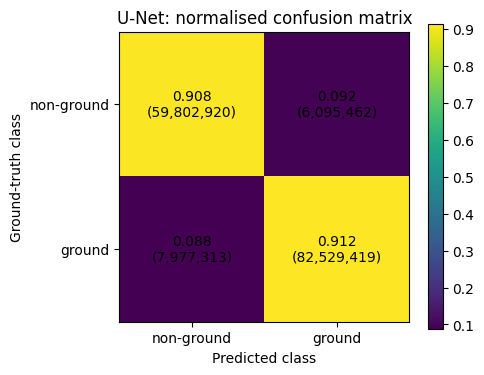

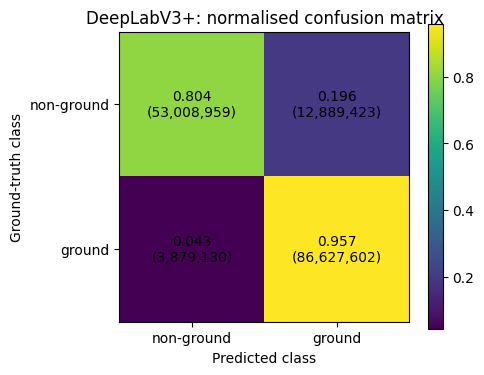

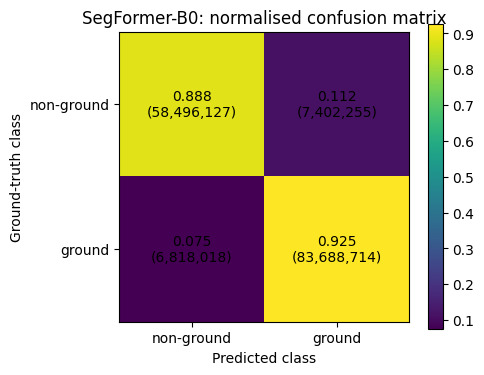

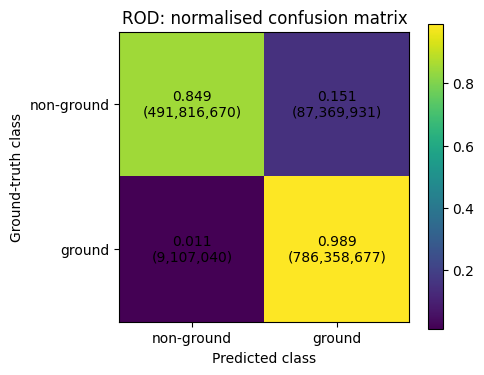

In [16]:
import matplotlib.pyplot as plt


def plot_confusion_matrix(cm, title):
    cm = cm.numpy().astype(np.float64)

    row_sums = cm.sum(axis=1, keepdims=True)
    normalized = np.divide(
        cm,
        row_sums,
        out=np.zeros_like(cm),
        where=row_sums != 0,
    )

    fig, ax = plt.subplots(figsize=(5, 4))
    image = ax.imshow(normalized)

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["non-ground", "ground"])
    ax.set_yticklabels(["non-ground", "ground"])
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("Ground-truth class")
    ax.set_title(title)

    for row in range(2):
        for column in range(2):
            ax.text(
                column,
                row,
                f"{normalized[row, column]:.3f}\n"
                f"({int(cm[row, column]):,})",
                ha="center",
                va="center",
            )

    fig.colorbar(image, ax=ax)
    plt.tight_layout()
    plt.show()


for model_name, cm in confusion_matrices.items():
    plot_confusion_matrix(
        cm,
        f"{model_name}: normalised confusion matrix",
    )


## 14. Prediction and qualitative visualisation helpers

In [17]:
from matplotlib.colors import ListedColormap


def denormalize_image(
    image_tensor,
    normalization,
):
    image = (
        image_tensor
        .detach()
        .cpu()
        .clone()
    )

    if normalization == "imagenet":
        mean = torch.tensor(
            IMAGENET_MEAN
        ).view(3, 1, 1)

        std = torch.tensor(
            IMAGENET_STD
        ).view(3, 1, 1)

        image = image * std + mean

    elif normalization == "rod_imagenet_255":
        # ROD visualisations use the original RGB image instead,
        # so this branch is included only for completeness.
        mean = torch.tensor(
            ROD_PIXEL_MEAN / 255.0
        ).view(3, 1, 1)

        std = torch.tensor(
            ROD_PIXEL_STD / 255.0
        ).view(3, 1, 1)

        image = image * std + mean

    image = image.clamp(0, 1)

    return (
        image
        .permute(1, 2, 0)
        .numpy()
    )


@torch.inference_mode()
def predict_single_image(
    model_name,
    model,
    image_path,
):
    config = MODEL_CONFIGS[
        model_name
    ]

    image = Image.open(
        image_path
    ).convert("RGB")

    # ----------------------------------------------------------
    # ROD: aspect-ratio-preserving resize/pad -> model ->
    # restore prediction to original resolution.
    # ----------------------------------------------------------
    if model_name == "ROD":
        rgb = np.array(
            image
        ).astype(np.float32) / 255.0

        image_np = np.array(
            image
        )

        padded_image, meta = rod_resize_pad(
            image_np,
            size=512,
        )

        tensor = (
            rod_normalize_image(
                padded_image
            )
            .unsqueeze(0)
            .to(DEVICE)
            .float()
        )

        output = model(
            tensor
        )

        logits = extract_logits(
            model_name,
            output,
            target_size=(512, 512),
        )

        padded_prediction = (
            torch.argmax(
                logits,
                dim=1,
            )[0]
            .cpu()
            .numpy()
            .astype(np.uint8)
        )

        prediction = restore_rod_prediction(
            padded_prediction,
            meta,
        )

        return rgb, prediction

    # ----------------------------------------------------------
    # Baseline models: direct 512x512 resize.
    # ----------------------------------------------------------
    resized = TF.resize(
        image,
        config["input_size"],
        interpolation=InterpolationMode.BILINEAR,
        antialias=True,
    )

    tensor = TF.to_tensor(
        resized
    )

    if config["normalization"] == "imagenet":
        tensor = TF.normalize(
            tensor,
            IMAGENET_MEAN,
            IMAGENET_STD,
        )

    tensor = (
        tensor
        .unsqueeze(0)
        .to(DEVICE)
    )

    output = model(
        tensor
    )

    logits = extract_logits(
        model_name,
        output,
        target_size=config["input_size"],
    )

    prediction = (
        torch.argmax(
            logits,
            dim=1,
        )[0]
        .cpu()
        .numpy()
        .astype(np.uint8)
    )

    rgb = (
        np.array(resized)
        .astype(np.float32)
        / 255.0
    )

    return rgb, prediction


def load_mask_at_model_size(
    model_name,
    mask_path,
):
    mask = Image.open(
        mask_path
    ).convert("L")

    if model_name == "ROD":
        return np.array(
            mask,
            dtype=np.uint8,
        )

    mask = TF.resize(
        mask,
        MODEL_CONFIGS[model_name]["input_size"],
        interpolation=InterpolationMode.NEAREST,
    )

    return np.array(
        mask,
        dtype=np.uint8,
    )


def binary_mask_for_display(mask):
    """
    Colour convention:
      black = non-ground
      white = ground
      gray  = ignore
    """
    vis = np.zeros_like(
        mask,
        dtype=np.uint8,
    )

    vis[
        mask == NON_GROUND_CLASS
    ] = 0

    vis[
        mask == GROUND_CLASS
    ] = 1

    vis[
        mask == IGNORE_INDEX
    ] = 2

    return vis


def make_ground_overlay(
    rgb,
    prediction,
    target,
    ignore_index=255,
    alpha=0.40,
):
    overlay = rgb.copy()

    valid_ground = (
        (prediction == GROUND_CLASS)
        & (target != ignore_index)
    )

    green = np.zeros_like(
        rgb
    )

    green[..., 1] = 1.0

    overlay[valid_ground] = (
        (1.0 - alpha)
        * rgb[valid_ground]
        + alpha
        * green[valid_ground]
    )

    return np.clip(
        overlay,
        0,
        1,
    )


def make_error_rgb(
    prediction,
    target,
    ignore_index=255,
):
    """
    red   = false ground
    blue  = false non-ground
    black = correct or ignored
    """
    error_rgb = np.zeros(
        (*target.shape, 3),
        dtype=np.uint8,
    )

    valid = (
        target != ignore_index
    )

    false_ground = (
        valid
        & (target == NON_GROUND_CLASS)
        & (prediction == GROUND_CLASS)
    )

    false_non_ground = (
        valid
        & (target == GROUND_CLASS)
        & (prediction == NON_GROUND_CLASS)
    )

    error_rgb[
        false_ground
    ] = [255, 0, 0]

    error_rgb[
        false_non_ground
    ] = [0, 0, 255]

    return error_rgb


import matplotlib.pyplot as plt
import numpy as np
from PIL import Image


def resize_rgb_to_original(rgb, original_size):
    """
    Resize RGB image back to the original RELLIS-3D image size.

    Parameters
    ----------
    rgb : np.ndarray
        RGB image, either float [0, 1] or uint8 [0, 255].
    original_size : tuple
        (height, width)

    Returns
    -------
    np.ndarray
        uint8 RGB image with original resolution.
    """
    original_h, original_w = original_size

    if rgb.dtype != np.uint8:
        rgb_uint8 = (np.clip(rgb, 0, 1) * 255).astype(np.uint8)
    else:
        rgb_uint8 = rgb

    rgb_resized = Image.fromarray(rgb_uint8).resize(
        (original_w, original_h),
        resample=Image.Resampling.BILINEAR
    )

    return np.array(rgb_resized)


def resize_mask_to_original(mask, original_size):
    """
    Resize segmentation mask back to the original RELLIS-3D image size.

    IMPORTANT:
    Nearest-neighbour interpolation must be used for masks.
    """
    original_h, original_w = original_size

    mask_uint8 = mask.astype(np.uint8)

    mask_resized = Image.fromarray(mask_uint8).resize(
        (original_w, original_h),
        resample=Image.Resampling.NEAREST
    )

    return np.array(mask_resized)


import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from PIL import Image


def resize_mask_to_original(mask, original_size):
    """
    Resize segmentation mask to original image size.

    Parameters
    ----------
    mask : np.ndarray
        Binary segmentation mask.

    original_size : tuple
        (height, width)
    """
    original_h, original_w = original_size

    mask = mask.astype(np.uint8)

    resized = Image.fromarray(mask).resize(
        (original_w, original_h),
        resample=Image.Resampling.NEAREST
    )

    return np.array(resized)


def visualise_case(
    model_name,
    model,
    image_path,
    mask_path,
    metrics,
    group_name,
    rank,
    save_root=None,
):
    # ----------------------------------------------------------
    # 1. Load original RGB image
    # ----------------------------------------------------------
    original_rgb_uint8 = np.array(
        Image.open(image_path).convert("RGB")
    )

    original_h, original_w = original_rgb_uint8.shape[:2]

    original_rgb = (
        original_rgb_uint8.astype(np.float32) / 255.0
    )

    # ----------------------------------------------------------
    # 2. Run prediction using existing preprocessing
    # ----------------------------------------------------------
    _, prediction = predict_single_image(
        model_name,
        model,
        image_path,
    )

    # ----------------------------------------------------------
    # 3. Load GT directly at ORIGINAL resolution
    # ----------------------------------------------------------
    target = np.array(
        Image.open(mask_path).convert("L"),
        dtype=np.uint8,
    )

    # ----------------------------------------------------------
    # 4. Resize prediction back to original resolution
    #    ONLY for visualisation
    # ----------------------------------------------------------
    if prediction.shape != target.shape:
        prediction = np.array(
            Image.fromarray(
                prediction.astype(np.uint8)
            ).resize(
                (original_w, original_h),
                resample=Image.Resampling.NEAREST,
            ),
            dtype=np.uint8,
        )

    # Safety check
    assert prediction.shape == target.shape, (
        f"Prediction shape {prediction.shape} "
        f"does not match target shape {target.shape}"
    )

    # ----------------------------------------------------------
    # 5. Prepare GT / prediction display
    # ----------------------------------------------------------
    mask_cmap = ListedColormap(
        ["black", "white", "gray"]
    )

    gt_vis = binary_mask_for_display(
        target
    )

    pred_vis = binary_mask_for_display(
        prediction
    )

    # Ignore pixels shown as gray
    pred_vis[
        target == IGNORE_INDEX
    ] = 2

    # ----------------------------------------------------------
    # 6. Overlay
    # ----------------------------------------------------------
    overlay = make_ground_overlay(
        rgb=original_rgb,
        prediction=prediction,
        target=target,
        ignore_index=IGNORE_INDEX,
        alpha=0.40,
    )

    # ----------------------------------------------------------
    # 7. Error map
    # ----------------------------------------------------------
    error_rgb = make_error_rgb(
        prediction=prediction,
        target=target,
        ignore_index=IGNORE_INDEX,
    )

    # ----------------------------------------------------------
    # 8. Plot
    # ----------------------------------------------------------
    figure, axes = plt.subplots(
        1,
        5,
        figsize=(23, 5),
    )

    axes[0].imshow(
        original_rgb
    )
    axes[0].set_title(
        "RGB"
    )

    axes[1].imshow(
        gt_vis,
        cmap=mask_cmap,
        vmin=0,
        vmax=2,
    )
    axes[1].set_title(
        "GT ground"
    )

    axes[2].imshow(
        pred_vis,
        cmap=mask_cmap,
        vmin=0,
        vmax=2,
    )
    axes[2].set_title(
        f"{model_name} prediction"
    )

    axes[3].imshow(
        overlay
    )
    axes[3].set_title(
        "Prediction overlay"
    )

    axes[4].imshow(
        error_rgb
    )
    axes[4].set_title(
        "Errors\n"
        "red=false ground\n"
        "blue=false non-ground"
    )

    for axis in axes:
        axis.axis("off")

    # ----------------------------------------------------------
    # 9. Title
    # ----------------------------------------------------------
    figure.suptitle(
        f"{Path(image_path).name}\n"
        f"{group_name} #{rank} | "
        f"mIoU={metrics['miou']:.4f} | "
        f"NG IoU={metrics['non_ground_iou']:.4f} | "
        f"G IoU={metrics['ground_iou']:.4f}",
        fontsize=11,
    )

    plt.tight_layout(
        rect=[0, 0, 1, 0.90]
    )

    # ----------------------------------------------------------
    # 10. Save
    # ----------------------------------------------------------
    if save_root is not None:
        safe_model = (
            model_name.lower()
            .replace("+", "plus")
            .replace("-", "_")
            .replace(" ", "_")
        )

        group_dir = (
            Path(save_root)
            / safe_model
            / group_name.lower()
            .replace(" ", "_")
            .replace("-", "")
        )

        group_dir.mkdir(
            parents=True,
            exist_ok=True,
        )

        figure.savefig(
            group_dir
            / f"{rank:02d}_{Path(image_path).stem}.png",
            dpi=180,
            bbox_inches="tight",
        )

    plt.show()
    plt.close(figure)



## 15. Select representative RUGD → RELLIS-3D cases with model-agnostic criteria

The qualitative examples are selected using neutral criteria so that no model
is assumed to be superior in advance.

The three final cases are:

1. **Successful transfer** — high average mIoU with low disagreement across the four models.
2. **Non-ground challenge** — ground IoU remains relatively strong while non-ground IoU is substantially lower.
3. **Model disagreement** — the four models show the largest spread in per-image mIoU.

For the third category, disagreement is defined as:

`max(per-image mIoU across models) - min(per-image mIoU across models)`

This criterion is independent of which model performs best.


In [18]:
# ================================================================
# 15. Merge per-image metrics from all four models
# ================================================================

MODEL_ORDER = [
    "U-Net",
    "DeepLabV3+",
    "SegFormer-B0",
    "ROD",
]

METRIC_COLUMNS = [
    "miou",
    "non_ground_iou",
    "ground_iou",
]

combined = None

for model_name in MODEL_ORDER:

    dataframe = per_image_results[
        model_name
    ].copy()

    subset = dataframe[
        [
            "image_path",
            "mask_path",
        ] + METRIC_COLUMNS
    ].copy()

    subset = subset.rename(
        columns={
            metric: f"{model_name}__{metric}"
            for metric in METRIC_COLUMNS
        }
    )

    if combined is None:
        combined = subset
    else:
        combined = combined.merge(
            subset,
            on=[
                "image_path",
                "mask_path",
            ],
            how="inner",
        )


miou_columns = [
    f"{name}__miou"
    for name in MODEL_ORDER
]

ng_columns = [
    f"{name}__non_ground_iou"
    for name in MODEL_ORDER
]

g_columns = [
    f"{name}__ground_iou"
    for name in MODEL_ORDER
]


combined["average_miou"] = combined[
    miou_columns
].mean(
    axis=1,
    skipna=True,
)

combined["std_miou"] = combined[
    miou_columns
].std(
    axis=1,
    skipna=True,
)

combined["average_non_ground_iou"] = combined[
    ng_columns
].mean(
    axis=1,
    skipna=True,
)

combined["average_ground_iou"] = combined[
    g_columns
].mean(
    axis=1,
    skipna=True,
)

combined["ground_minus_non_ground"] = (
    combined["average_ground_iou"]
    - combined["average_non_ground_iou"]
)

combined["best_model_miou"] = combined[
    miou_columns
].max(
    axis=1,
    skipna=True,
)

combined["worst_model_miou"] = combined[
    miou_columns
].min(
    axis=1,
    skipna=True,
)

combined["model_disagreement"] = (
    combined["best_model_miou"]
    - combined["worst_model_miou"]
)


required_score_columns = [
    "average_miou",
    "std_miou",
    "average_non_ground_iou",
    "average_ground_iou",
    "ground_minus_non_ground",
    "best_model_miou",
    "worst_model_miou",
    "model_disagreement",
]

selection_df = combined.dropna(
    subset=required_score_columns
).copy()

print(
    f"Images available for representative-case selection: "
    f"{len(selection_df)}"
)

display(
    selection_df[
        [
            "image_path",
            "average_miou",
            "std_miou",
            "average_non_ground_iou",
            "average_ground_iou",
            "model_disagreement",
        ]
    ].head()
)


Images available for representative-case selection: 899


,image_path,average_miou,std_miou,average_non_ground_iou,average_ground_iou,model_disagreement
0,/content/rellis_test_data/RELLIS_3D_binary_pro...,0.932372,0.043850,0.920133,0.944611,0.100016
1,/content/rellis_test_data/RELLIS_3D_binary_pro...,0.903944,0.049274,0.889860,0.918028,0.113005
2,/content/rellis_test_data/RELLIS_3D_binary_pro...,0.899388,0.056981,0.885221,0.913554,0.125839
3,/content/rellis_test_data/RELLIS_3D_binary_pro...,0.927857,0.054997,0.916860,0.938854,0.119020
4,/content/rellis_test_data/RELLIS_3D_binary_pro...,0.914863,0.052817,0.902404,0.927322,0.115474


## 16. Rank the three representative candidate groups

Ten candidates are retained for each category so that visually repetitive
frames can be avoided without changing the underlying metric-based selection.


In [19]:
# ================================================================
# 16. Representative-case ranking
# ================================================================

REPRESENTATIVE_DIR = (
    RESULTS_ROOT
    / "representative_cases_3x6_model_agnostic"
)

REPRESENTATIVE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

CANDIDATES_PER_CATEGORY = 10


# ================================================================
# 1. Successful transfer
# ================================================================

successful_pool = selection_df[
    selection_df["average_miou"]
    >= selection_df["average_miou"].quantile(0.80)
].copy()

successful_pool["selection_score"] = (
    successful_pool["average_miou"]
    - 0.50 * successful_pool["std_miou"]
)

successful_candidates = (
    successful_pool
    .sort_values(
        "selection_score",
        ascending=False,
    )
    .head(CANDIDATES_PER_CATEGORY)
    .copy()
)


# ================================================================
# 2. Non-ground challenge
#
# Ground remains reasonably strong while non-ground is weaker.
# ================================================================

ground_threshold = selection_df[
    "average_ground_iou"
].median()

ng_pool = selection_df[
    selection_df["average_ground_iou"]
    >= ground_threshold
].copy()

ng_pool["selection_score"] = (
    ng_pool["ground_minus_non_ground"]
    + 0.25 * (
        1.0
        - ng_pool["average_non_ground_iou"]
    )
)

non_ground_candidates = (
    ng_pool
    .sort_values(
        "selection_score",
        ascending=False,
    )
    .head(CANDIDATES_PER_CATEGORY)
    .copy()
)


# ================================================================
# 3. Model disagreement
#
# Largest mIoU range across all four models.
# ================================================================

disagreement_candidates = (
    selection_df
    .sort_values(
        "model_disagreement",
        ascending=False,
    )
    .head(CANDIDATES_PER_CATEGORY)
    .copy()
)


candidate_tables = {
    "01_successful_transfer": successful_candidates,
    "02_non_ground_challenge": non_ground_candidates,
    "03_model_disagreement": disagreement_candidates,
}

CASE_LABELS = {
    "01_successful_transfer": "Successful transfer",
    "02_non_ground_challenge": "Non-ground challenge",
    "03_model_disagreement": "Model disagreement",
}


for category, candidate_df in candidate_tables.items():

    candidate_path = (
        REPRESENTATIVE_DIR
        / f"{category}_top{CANDIDATES_PER_CATEGORY}_candidates.csv"
    )

    candidate_df.to_csv(
        candidate_path,
        index=False,
    )


print("=== SUCCESSFUL TRANSFER ===")
display(
    successful_candidates[
        [
            "image_path",
            "average_miou",
            "std_miou",
            "average_non_ground_iou",
            "average_ground_iou",
        ]
    ]
)

print("=== NON-GROUND CHALLENGE ===")
display(
    non_ground_candidates[
        [
            "image_path",
            "average_miou",
            "average_non_ground_iou",
            "average_ground_iou",
            "ground_minus_non_ground",
        ]
    ]
)

print("=== MODEL DISAGREEMENT ===")
display(
    disagreement_candidates[
        [
            "image_path",
            "average_miou",
            "model_disagreement",
            "best_model_miou",
            "worst_model_miou",
            "U-Net__miou",
            "DeepLabV3+__miou",
            "SegFormer-B0__miou",
            "ROD__miou",
        ]
    ]
)


=== SUCCESSFUL TRANSFER ===


,image_path,average_miou,std_miou,average_non_ground_iou,average_ground_iou
890,/content/rellis_test_data/RELLIS_3D_binary_pro...,0.974412,0.006149,0.967444,0.981380
897,/content/rellis_test_data/RELLIS_3D_binary_pro...,0.974172,0.005878,0.964790,0.983554
892,/content/rellis_test_data/RELLIS_3D_binary_pro...,0.974219,0.009055,0.965532,0.982906
888,/content/rellis_test_data/RELLIS_3D_binary_pro...,0.974256,0.010670,0.968030,0.980482
889,/content/rellis_test_data/RELLIS_3D_binary_pro...,0.971914,0.007103,0.963462,0.980365
894,/content/rellis_test_data/RELLIS_3D_binary_pro...,0.968552,0.006746,0.956815,0.980290
887,/content/rellis_test_data/RELLIS_3D_binary_pro...,0.967752,0.005974,0.959576,0.975928
860,/content/rellis_test_data/RELLIS_3D_binary_pro...,0.968107,0.007287,0.956097,0.980117
883,/content/rellis_test_data/RELLIS_3D_binary_pro...,0.968084,0.007352,0.958834,0.977334
885,/content/rellis_test_data/RELLIS_3D_binary_pro...,0.969907,0.013454,0.962584,0.977230


=== NON-GROUND CHALLENGE ===


,image_path,average_miou,average_non_ground_iou,average_ground_iou,ground_minus_non_ground
121,/content/rellis_test_data/RELLIS_3D_binary_pro...,0.817332,0.744047,0.890616,0.146569
133,/content/rellis_test_data/RELLIS_3D_binary_pro...,0.814600,0.743894,0.885307,0.141413
151,/content/rellis_test_data/RELLIS_3D_binary_pro...,0.816289,0.749765,0.882813,0.133048
814,/content/rellis_test_data/RELLIS_3D_binary_pro...,0.828456,0.761992,0.894919,0.132927
120,/content/rellis_test_data/RELLIS_3D_binary_pro...,0.838374,0.771114,0.905634,0.134521
136,/content/rellis_test_data/RELLIS_3D_binary_pro...,0.830663,0.764282,0.897044,0.132762
746,/content/rellis_test_data/RELLIS_3D_binary_pro...,0.816539,0.752026,0.881053,0.129027
152,/content/rellis_test_data/RELLIS_3D_binary_pro...,0.827335,0.763164,0.891505,0.128341
733,/content/rellis_test_data/RELLIS_3D_binary_pro...,0.830093,0.766671,0.893516,0.126845
156,/content/rellis_test_data/RELLIS_3D_binary_pro...,0.848877,0.783572,0.914182,0.130609


=== MODEL DISAGREEMENT ===


,image_path,average_miou,model_disagreement,best_model_miou,worst_model_miou,U-Net__miou,DeepLabV3+__miou,SegFormer-B0__miou,ROD__miou
686,/content/rellis_test_data/RELLIS_3D_binary_pro...,0.542240,0.494973,0.769634,0.274661,0.420128,0.274661,0.704536,0.769634
693,/content/rellis_test_data/RELLIS_3D_binary_pro...,0.624750,0.473174,0.875236,0.402061,0.619335,0.402061,0.602369,0.875236
687,/content/rellis_test_data/RELLIS_3D_binary_pro...,0.637175,0.448119,0.800747,0.352628,0.352628,0.675821,0.719503,0.800747
692,/content/rellis_test_data/RELLIS_3D_binary_pro...,0.612252,0.430811,0.812352,0.381541,0.580199,0.381541,0.674915,0.812352
813,/content/rellis_test_data/RELLIS_3D_binary_pro...,0.818492,0.421338,0.954101,0.532762,0.532762,0.848697,0.938407,0.954101
709,/content/rellis_test_data/RELLIS_3D_binary_pro...,0.698412,0.419969,0.827848,0.407879,0.827848,0.407879,0.742003,0.815920
670,/content/rellis_test_data/RELLIS_3D_binary_pro...,0.701496,0.418177,0.828039,0.409862,0.781309,0.409862,0.828039,0.786775
697,/content/rellis_test_data/RELLIS_3D_binary_pro...,0.606302,0.417175,0.772651,0.355476,0.625884,0.355476,0.671197,0.772651
666,/content/rellis_test_data/RELLIS_3D_binary_pro...,0.659484,0.405361,0.825469,0.420108,0.706653,0.420108,0.685708,0.825469
707,/content/rellis_test_data/RELLIS_3D_binary_pro...,0.567055,0.397670,0.703026,0.305356,0.642927,0.305356,0.616912,0.703026


## 17. Preview the top-10 RGB candidates and choose the final three

The preview is only for checking scene diversity. The highest-ranked candidate
is used by default. If another candidate is visually more representative,
change its rank in `MANUAL_SELECTION`.


In [20]:
# ================================================================
# 17. Candidate preview and optional manual override
# ================================================================

MANUAL_SELECTION = {
    "01_successful_transfer": 1,
    "02_non_ground_challenge": 1,
    "03_model_disagreement": 1,
}


def preview_category_candidates(
    category,
    candidate_df,
    max_images=10,
):

    n = min(
        max_images,
        len(candidate_df),
    )

    if n == 0:
        print(
            f"No candidates for {category}"
        )
        return

    figure, axes = plt.subplots(
        2,
        5,
        figsize=(18, 7),
    )

    axes = np.array(
        axes
    ).reshape(-1)

    for i in range(10):

        axis = axes[i]

        if i >= n:
            axis.axis("off")
            continue

        row = candidate_df.iloc[i]

        rgb = np.array(
            Image.open(
                row["image_path"]
            ).convert("RGB")
        )

        axis.imshow(
            rgb
        )

        if category == "03_model_disagreement":

            axis.set_title(
                f"#{i + 1} | disagreement={row['model_disagreement']:.3f}\n"
                f"U={row['U-Net__miou']:.3f}, "
                f"D={row['DeepLabV3+__miou']:.3f}, "
                f"S={row['SegFormer-B0__miou']:.3f}, "
                f"R={row['ROD__miou']:.3f}",
                fontsize=8,
            )

        else:

            axis.set_title(
                f"#{i + 1} | avg mIoU={row['average_miou']:.3f}\n"
                f"NG={row['average_non_ground_iou']:.3f}, "
                f"G={row['average_ground_iou']:.3f}",
                fontsize=9,
            )

        axis.axis(
            "off"
        )

    figure.suptitle(
        CASE_LABELS.get(
            category,
            category,
        ),
        fontsize=14,
    )

    plt.tight_layout(
        rect=[0, 0, 1, 0.95]
    )

    plt.show()
    plt.close(
        figure
    )


for category, candidate_df in candidate_tables.items():

    preview_category_candidates(
        category,
        candidate_df,
        max_images=CANDIDATES_PER_CATEGORY,
    )


# ================================================================
# Resolve final selections and avoid exact duplicate frames
# ================================================================

final_rows = []
used_paths = set()

for category in [
    "01_successful_transfer",
    "02_non_ground_challenge",
    "03_model_disagreement",
]:

    candidate_df = candidate_tables[
        category
    ]

    requested_rank = int(
        MANUAL_SELECTION[
            category
        ]
    )

    if not 1 <= requested_rank <= len(candidate_df):
        raise ValueError(
            f"{category}: rank {requested_rank} "
            f"is outside 1..{len(candidate_df)}"
        )

    ordered_positions = (
        list(
            range(
                requested_rank - 1,
                len(candidate_df),
            )
        )
        + list(
            range(
                0,
                requested_rank - 1,
            )
        )
    )

    chosen = None

    for position in ordered_positions:

        row = candidate_df.iloc[
            position
        ].copy()

        image_path = str(
            row["image_path"]
        )

        if image_path not in used_paths:
            chosen = row
            used_paths.add(
                image_path
            )
            break

    if chosen is None:
        raise RuntimeError(
            f"No unused candidate remained for {category}"
        )

    chosen["case_key"] = category
    chosen["case_label"] = CASE_LABELS[
        category
    ]

    final_rows.append(
        chosen
    )


final_cases = pd.DataFrame(
    final_rows
).reset_index(
    drop=True
)

FINAL_CASES_CSV = (
    REPRESENTATIVE_DIR
    / "final_representative_cases.csv"
)

final_cases.to_csv(
    FINAL_CASES_CSV,
    index=False,
)

display(
    final_cases[
        [
            "case_label",
            "image_path",
            "average_miou",
            "average_non_ground_iou",
            "average_ground_iou",
            "model_disagreement",
        ]
    ]
)

print(
    "Saved:",
    FINAL_CASES_CSV,
)


Output hidden; open in https://colab.research.google.com to view.

## 18. Generate the final 3 × 6 error-overlay figure

The display style matches the latest in-domain and ORFD figures:

`Input | Ground Truth | U-Net | DeepLabV3+ | SegFormer-B0 | ROD`

- **black** = correct non-ground
- **white** = correct ground
- **red** = false ground (`GT non-ground → predicted ground`)
- **blue** = false non-ground (`GT ground → predicted non-ground`)
- **gray** = ignore

The image filename is not displayed. Each model panel retains the per-image mIoU.


In [21]:
# ================================================================
# Load all four models for final qualitative visualisation
# ================================================================

# The quantitative evaluation above loads each model one at a time and then
# releases it to save GPU memory. The final 3x6 figure needs all four models
# available again, so reload them here and keep them in a dictionary.

loaded_models = {}

MODEL_ORDER_FOR_VIS = [
    "U-Net",
    "DeepLabV3+",
    "SegFormer-B0",
    "ROD",
]

for model_name in MODEL_ORDER_FOR_VIS:

    print(f"Loading {model_name} for qualitative visualisation ...")

    checkpoint_path = CHECKPOINTS[model_name]

    checkpoint = load_checkpoint_file(
        checkpoint_path
    )

    model = build_model(
        model_name,
        checkpoint=checkpoint,
    )

    load_checkpoint_into_model(
        model,
        checkpoint,
        strict=True,
    )

    model = model.to(DEVICE)
    model.eval()

    loaded_models[model_name] = model

print(
    "Models kept in memory:",
    list(loaded_models.keys()),
)


Loading U-Net for qualitative visualisation ...
Loading DeepLabV3+ for qualitative visualisation ...
Loading SegFormer-B0 for qualitative visualisation ...
Loading ROD for qualitative visualisation ...
Models kept in memory: ['U-Net', 'DeepLabV3+', 'SegFormer-B0', 'ROD']


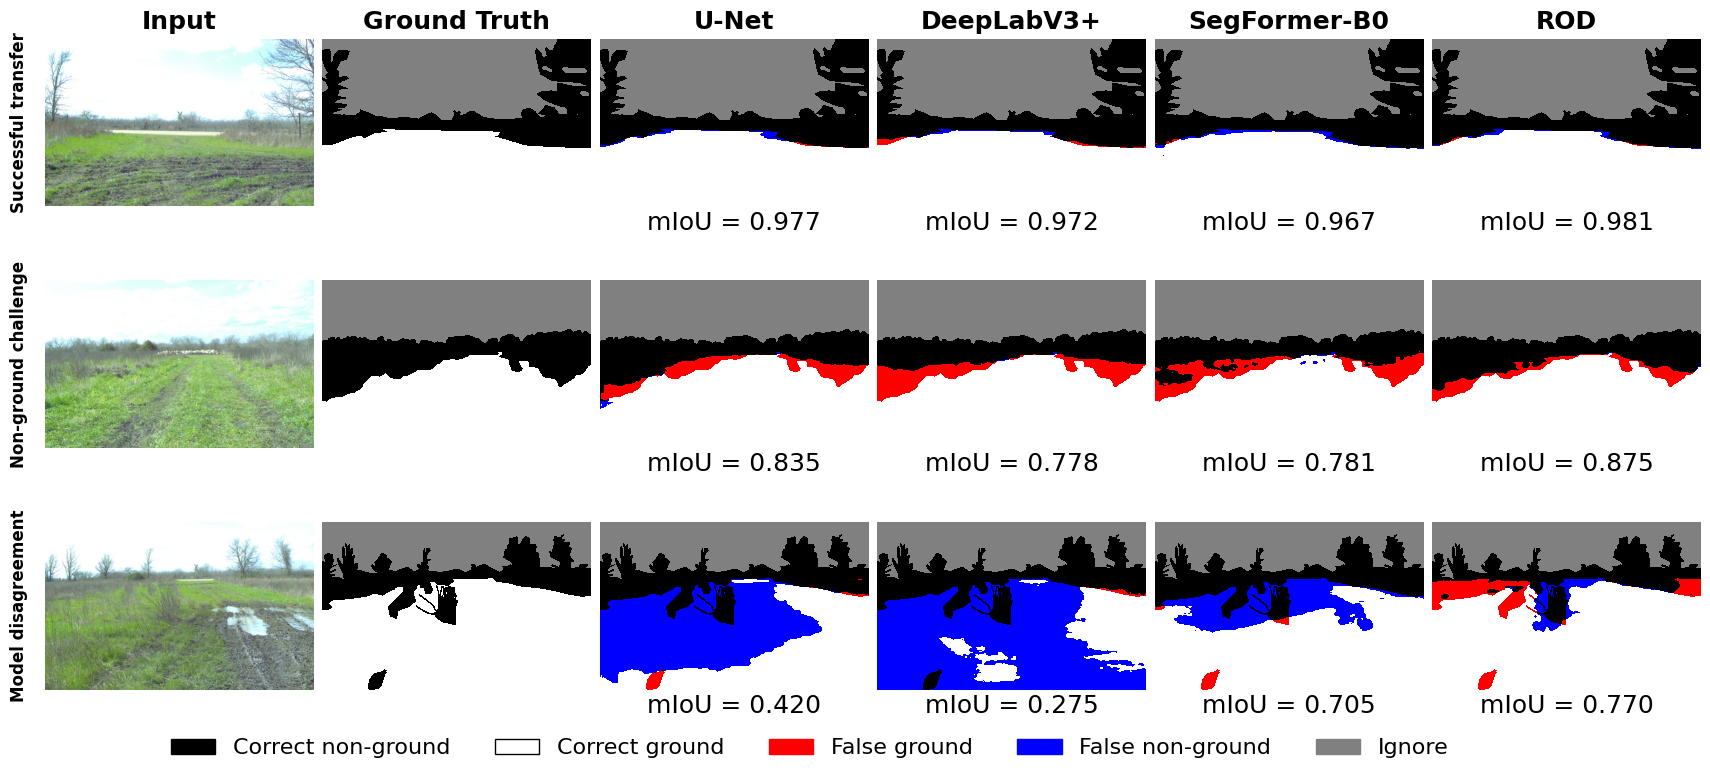

Saved final RUGD -> RELLIS-3D figure:
PNG: /content/drive/MyDrive/IRP/03_cross_dataset/rugd_to_rellis3d/representative_cases_3x6_model_agnostic/rugd_to_rellis3d_model_agnostic_3x6_error_overlay.png
PDF: /content/drive/MyDrive/IRP/03_cross_dataset/rugd_to_rellis3d/representative_cases_3x6_model_agnostic/rugd_to_rellis3d_model_agnostic_3x6_error_overlay.pdf


In [25]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch


@torch.inference_mode()
def get_prediction_at_original_size(
    model_name,
    image_path,
    target_shape,
):

    model = loaded_models[
        model_name
    ]

    _, prediction = predict_single_image(
        model_name,
        model,
        image_path,
    )

    target_h, target_w = target_shape

    if prediction.shape != (
        target_h,
        target_w,
    ):

        prediction = np.array(
            Image.fromarray(
                prediction.astype(
                    np.uint8
                )
            ).resize(
                (
                    target_w,
                    target_h,
                ),
                resample=Image.Resampling.NEAREST,
            ),
            dtype=np.uint8,
        )

    return prediction


def make_prediction_error_map(
    prediction,
    target,
    ignore_index=IGNORE_INDEX,
):

    error_map = np.full(
        target.shape,
        4,
        dtype=np.uint8,
    )

    valid = target != ignore_index

    # Correct non-ground
    error_map[
        valid
        & (target == 0)
        & (prediction == 0)
    ] = 0

    # Correct ground
    error_map[
        valid
        & (target == 1)
        & (prediction == 1)
    ] = 1

    # False ground
    error_map[
        valid
        & (target == 0)
        & (prediction == 1)
    ] = 2

    # False non-ground
    error_map[
        valid
        & (target == 1)
        & (prediction == 0)
    ] = 3

    return error_map


def make_representative_figure_3x6(
    final_cases,
    save_dir,
    dpi=300,
):

    model_order = [
        "U-Net",
        "DeepLabV3+",
        "SegFormer-B0",
        "ROD",
    ]

    column_titles = [
        "Input",
        "Ground Truth",
        "U-Net",
        "DeepLabV3+",
        "SegFormer-B0",
        "ROD",
    ]

    error_cmap = ListedColormap(
        [
            "black",
            "white",
            "red",
            "blue",
            "gray",
        ]
    )

    gt_cmap = ListedColormap(
        [
            "black",
            "white",
            "gray",
        ]
    )

    n_rows = len(
        final_cases
    )

    n_cols = len(
        column_titles
    )

    figure, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(18, 8.0),
        squeeze=False,
    )

    for row_index, (_, case) in enumerate(
        final_cases.iterrows()
    ):

        image_path = case[
            "image_path"
        ]

        mask_path = case[
            "mask_path"
        ]

        original_rgb = np.array(
            Image.open(
                image_path
            ).convert("RGB")
        )

        target = np.array(
            Image.open(
                mask_path
            ).convert("L"),
            dtype=np.uint8,
        )

        original_h, original_w = (
            original_rgb.shape[:2]
        )

        if target.shape != (
            original_h,
            original_w,
        ):

            target = np.array(
                Image.fromarray(
                    target
                ).resize(
                    (
                        original_w,
                        original_h,
                    ),
                    resample=Image.Resampling.NEAREST,
                ),
                dtype=np.uint8,
            )

        gt_vis = binary_mask_for_display(
            target
        )

        axes[
            row_index,
            0,
        ].imshow(
            original_rgb
        )

        axes[
            row_index,
            0,
        ].set_xlabel("")

        axes[
            row_index,
            1,
        ].imshow(
            gt_vis,
            cmap=gt_cmap,
            vmin=0,
            vmax=2,
            interpolation="nearest",
        )

        for model_offset, model_name in enumerate(
            model_order,
            start=2,
        ):

            prediction = get_prediction_at_original_size(
                model_name=model_name,
                image_path=image_path,
                target_shape=target.shape,
            )

            error_map = make_prediction_error_map(
                prediction=prediction,
                target=target,
                ignore_index=IGNORE_INDEX,
            )

            axes[
                row_index,
                model_offset,
            ].imshow(
                error_map,
                cmap=error_cmap,
                vmin=0,
                vmax=4,
                interpolation="nearest",
            )

            model_miou = case[
                f"{model_name}__miou"
            ]

            axes[
                row_index,
                model_offset,
            ].set_xlabel(
                f"mIoU = {model_miou:.3f}",
                fontsize=18,
                labelpad=3,
            )

        axes[
            row_index,
            0,
        ].set_ylabel(
            case["case_label"],
            fontsize=12,
            rotation=90,
            labelpad=12,
            fontweight="bold",
        )

        for col_index in range(
            n_cols
        ):

            axes[
                row_index,
                col_index,
            ].set_xticks([])

            axes[
                row_index,
                col_index,
            ].set_yticks([])

            for spine in axes[
                row_index,
                col_index,
            ].spines.values():

                spine.set_visible(
                    False
                )

    for col_index, title in enumerate(
        column_titles
    ):

        axes[
            0,
            col_index,
        ].set_title(
            title,
            fontsize=18,
            fontweight="bold",
            pad=7,
        )

    legend_elements = [
        Patch(
            facecolor="black",
            edgecolor="black",
            label="Correct non-ground",
        ),
        Patch(
            facecolor="white",
            edgecolor="black",
            label="Correct ground",
        ),
        Patch(
            facecolor="red",
            edgecolor="red",
            label="False ground",
        ),
        Patch(
            facecolor="blue",
            edgecolor="blue",
            label="False non-ground",
        ),
        Patch(
            facecolor="gray",
            edgecolor="gray",
            label="Ignore",
        ),
    ]

    figure.legend(
        handles=legend_elements,
        loc="lower center",
        ncol=5,
        fontsize=16,
        frameon=False,
        bbox_to_anchor=(
            0.5,
            0.005,
        ),
    )

    figure.subplots_adjust(
        left=0.075,
        right=0.995,
        top=0.955,
        bottom=0.09,
        wspace=0.035,
        hspace=0.16,
    )

    save_dir = Path(
        save_dir
    )

    save_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    png_path = (
        save_dir
        / "rugd_to_rellis3d_model_agnostic_3x6_error_overlay.png"
    )

    pdf_path = (
        save_dir
        / "rugd_to_rellis3d_model_agnostic_3x6_error_overlay.pdf"
    )

    figure.savefig(
        png_path,
        dpi=dpi,
        bbox_inches="tight",
        pad_inches=0.03,
    )

    figure.savefig(
        pdf_path,
        bbox_inches="tight",
        pad_inches=0.03,
    )

    plt.show()
    plt.close(
        figure
    )

    return (
        png_path,
        pdf_path,
    )


figure_png, figure_pdf = make_representative_figure_3x6(
    final_cases=final_cases,
    save_dir=REPRESENTATIVE_DIR,
    dpi=300,
)

print(
    "Saved final RUGD -> RELLIS-3D figure:"
)
print(
    "PNG:",
    figure_png,
)
print(
    "PDF:",
    figure_pdf,
)


## 19. Export selected-case summary


In [23]:
summary_columns = [
    "case_label",
    "image_path",
    "average_miou",
    "average_non_ground_iou",
    "average_ground_iou",
    "model_disagreement",
    "best_model_miou",
    "worst_model_miou",
    "U-Net__miou",
    "DeepLabV3+__miou",
    "SegFormer-B0__miou",
    "ROD__miou",
]

selected_summary_df = final_cases[
    summary_columns
].copy()

SELECTED_SUMMARY_CSV = (
    REPRESENTATIVE_DIR
    / "selected_representative_cases_summary.csv"
)

selected_summary_df.to_csv(
    SELECTED_SUMMARY_CSV,
    index=False,
)

display(
    selected_summary_df
)

print(
    "Saved:",
    SELECTED_SUMMARY_CSV,
)


,case_label,image_path,average_miou,average_non_ground_iou,average_ground_iou,model_disagreement,best_model_miou,worst_model_miou,U-Net__miou,DeepLabV3+__miou,SegFormer-B0__miou,ROD__miou
0,Successful transfer,/content/rellis_test_data/RELLIS_3D_binary_pro...,0.974412,0.967444,0.981380,0.014083,0.981147,0.967064,0.977352,0.972085,0.967064,0.981147
1,Non-ground challenge,/content/rellis_test_data/RELLIS_3D_binary_pro...,0.817332,0.744047,0.890616,0.097077,0.875198,0.778121,0.834879,0.778121,0.781129,0.875198
2,Model disagreement,/content/rellis_test_data/RELLIS_3D_binary_pro...,0.542240,0.496212,0.588267,0.494973,0.769634,0.274661,0.420128,0.274661,0.704536,0.769634


Saved: /content/drive/MyDrive/IRP/03_cross_dataset/rugd_to_rellis3d/representative_cases_3x6_model_agnostic/selected_representative_cases_summary.csv


## Interpretation

The three qualitative rows are now selected with model-agnostic criteria:

- successful transfer,
- non-ground difficulty,
- inter-model disagreement.

The third row no longer assumes that ROD is the best model. Whichever model
performs best in the disagreement case is observed after the image has been
selected.
